In [5]:
#    Define input file for BOUT++

import numpy as np
import scipy
import xbout
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 200  
plt.ioff()
#%load_ext autoreload
#%autoreload 2
params = {'legend.fontsize': 8,
'legend.title_fontsize': 8,
'figure.figsize': (4.8, 4.8),
'axes.labelsize': 12,
'axes.titlesize': 15,
'xtick.labelsize':8,
'ytick.labelsize':8,
'font.family': 'serif',
'text.usetex': False}
plt.rcParams.update(params)



def write_BOUT_inp(grid,solution,source,xmin,xmax,nx,D_par,D_perp,nout=100,timestep=2.0):
    # Normalization, beacuse x does indeed not go from 0 to 1, this screws up
    # the calculation for the perp derivatives
    
    minvalue=(-2.0+0.5) / (nx - 2*2)
    maxvalue=(nx-3+0.5) / (nx - 2*2)
    
    
    cont = f"""
#
# Input file for 1D wave MMS test
#

nout = {nout}      # Number of output timesteps
timestep = 20.0*pi/nout  #Time between outputs
#timestep = 1e-2

grid = "{grid}"


xl= ({np.round(xmax-xmin,2)})*(x-({np.round(minvalue,8)}))/(({np.round(maxvalue,8)})-({np.round(minvalue,8)})) + ({np.round(xmin,2)})
yl=y    #/(2*pi)
zl=z

evolve_Ne = true

MXG=2
MYG=1

[mesh:paralleltransform]
type = fci


[input]
error_on_unused_options=false


[mesh]

symmetricGlobalX = true

extrapolate_y = false

##################################################
[mesh:ddx]   # Methods used for perp (x) derivative terms

first = C2
second = C2
upwind = U1
flux = SPLIT

[mesh:ddy]   # Methods used for parallel (y) derivative terms

first = C2
second = C2
upwind = U1
flux = SPLIT

[mesh:ddz]   # Methods used for perp (z) derivative terms

first = C2
second = C2
upwind = U1
flux = SPLIT

[solver]

mms = true
mms_initialise = true
atol = 1e-12 # absolute tolerance
rtol = 1e-8  # relative tolerance
mxstep = 1000000

[Ne]
Ne_gradpar = false
Ne_diffusion_par = true
Ne_diffusion_perp = true
Ne_D2DX2 = false
Ne_D2DZ2 = false

D_par = {D_par}
D_perp = {D_perp}

bndry_xin = dirichlet(Ne:solution)
bndry_xout = dirichlet(Ne:solution)

solution = {solution}

source = {source}


    """
    return cont

def write_slurmfile(id,nodes,ntasks_per_node, mem,time_h,time_min,
                   executable,directory):
    content=f"""#!/bin/bash -l                                                                                                                                        
# Standard output and error:                                                                                                                          
#SBATCH -o ./job_hybrid.out.%j                                                                                                                        
#SBATCH -e ./job_hybrid.err.%j                                                                                                                        
# Initial working directory:                                                                                                                          
#SBATCH -D ./                                                                                                                                         
# Job Name:                                                                                                                                           
#SBATCH -J MMS_axial_circle_{int(id)}                                                                                                                         
#                                                                                                                                                     
# Number of nodes and MPI tasks per node:                                                                                                             
#SBATCH --nodes={nodes}                                                                                                                                    
#SBATCH --ntasks-per-node={int(ntasks_per_node)}                                                                                                                          
#SBATCH --mem={int(mem)}GB                                                                                                                                    

# for OpenMP:                                                                                                                                         
#SBATCH --cpus-per-task=1                                                                                                                             
#SBATCH --mail-type=all                                                                                                                               
#SBATCH --mail-user=toto@ipp.mpg.de                                                                                                                   
#                                                                                                                                                     
# Wall clock limit (max. is 24 hours):                                                                                                                
#SBATCH --time={int(time_h)}:{int(time_min)}:00                                                                                                                               
set -x
# Load compiler and MPI modules (must be the same as used for compiling the code)                                                                     
module purge
module load gcc/13 openmpi/4.1 hdf5-serial/1.14.1 netcdf-serial/4.9.2 fftw-mpi/3.3.10 anaconda/3/2021.11 mkl/2024.0

export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

# For pinning threads correctly:                                                                                                                      
export OMP_PLACES=cores

# Run the program                                                                                                                                     

srun {executable} -d {directory} $@
    
    """
    return content


def gridfile_string(nx,ny,nz,rho_1,xmin,xmax,Ly,B0,q0,q1,directory):
    content = f"{directory}/cor_mms_Axial_Circle_{nx}_{ny}_{nz}_{rho_1}_{xmin}_{xmax}_{np.round(Ly,3)}_{B0}_{q0}_{q1}.fci.grid.nc"
    return content

def read_solution_source():
    with open(f"solution.txt", "r") as file:
        solution = file.read()
        
    with open(f"source.txt", "r") as file:
        source = file.read()
    
    return solution,source

In [7]:
grids=[]
grids.append([20,16,64])
grids.append([36,32,128])
grids.append([52,48,192])
grids.append([68,64,256])

ntasks=[16,32,64,128]
comptimes=[1,1,2,2]

rundir="/u/toto/soft/hermes-2-new/hermes-2/MMS/axial_circular"

for i in range(len(grids)):
    id = i
    grindfilename=gridfile_string(nx=grids[i][0],ny=grids[i][1],nz=grids[i][2],rho_1=0.0,xmin=0.4,xmax=0.6,Ly=2*np.pi,B0=1.0,q0=8.0,q1=-0.2,
                                 directory=rundir)
    solution,source = read_solution_source()
    BOUTinp=write_BOUT_inp(grid=grindfilename,solution=solution,source=source,xmin=0.4,xmax=0.6,nx=grids[i][0],
                           nout=100,D_par = 1.0,D_perp = 1e-5)
    exec_dir="/u/toto/soft/hermes-2-new/hermes-2/MMS/axial_circular/build/Loki"
    directory=f"{rundir}/data_{id}"
    slurmbatch=write_slurmfile(id,1,ntasks[i],64,comptimes[i],0,exec_dir,directory)

    with open(f"data_{int(id)}/BOUT.inp", "w") as file:
        file.write(BOUTinp)

    with open(f"data_{int(id)}/slurmbatch", "w") as file:
        file.write(slurmbatch)


In [5]:
L2={}
Linf={}
yspacings={}
var="Ne"
xfit=[]
yfit=[]
for i in range(4):
    id = i
    try:
        grindfilename=gridfile_string(nx=grids[i][0],ny=grids[i][1],nz=grids[i][2],rho_1=0.0,xmin=0.4,xmax=0.6,Ly=2*np.pi,B0=1.0,q0=8.0,q1=-0.2,
                                     directory=rundir)
        results=xbout.open_boutdataset(datapath=f"{rundir}/data_{id}/BOUT.dmp.nc",
                              gridfilepath=grindfilename,geometry="fci")
        yspacings[str(id)]=results.y.size
        xfit.append(results.y.size)
        nt=results["t"].size
        L2[str(id)]=np.sqrt(((results["E_"+var])**2).isel(x=slice(2,-2),t=slice(None,None),z=slice(None,None)).mean()).values
        yfit.append(L2[str(id)])
        Linf[str(id)]=results["E_"+var].isel(x=slice(2,-2),t=slice(None,None),z=slice(None,None)).max()
    except:
        print(f"Failed at {i}")
    
initial_guesses = [5, -2.0]
xfit=1.0/np.array(xfit)
yfit=np.array(yfit)


def fitfunction(x,a,b):
    return a*x**b


popt_N, pcov_N = curve_fit(fitfunction, xfit,yfit, maxfev=1000,p0=initial_guesses)



Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (x: 20, y: 16, z: 64, t: 101)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(20, 16, 64), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(20, 16, 64), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(20, 16, 64), meta=np.ndarray>
  * t                   (t) float64 0.0 0.6283 1.257 1.885 ... 61.58 62.2 62.83
    R                   (x, y, z) float64 0.3995 0.3957 0.388 ... 0.5935 0.5993
    Z                   (x, y, z) float64 0.01963 0.05869 ... -0.08804 -0.02944
  * x                   (x) int64 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19
  * y                   (y) float64 0.1963 0.589 0.9817 ... 5.301 5.694 6.087
  * z                   (z) float64 0.0 0.09817 0.1963 ... 5.989 6.087 6.185
Data variables: (12/45)
    Bxy                 (x, y, z) float64 dask.array<chunksize

<IPython.core.display.Javascript object>


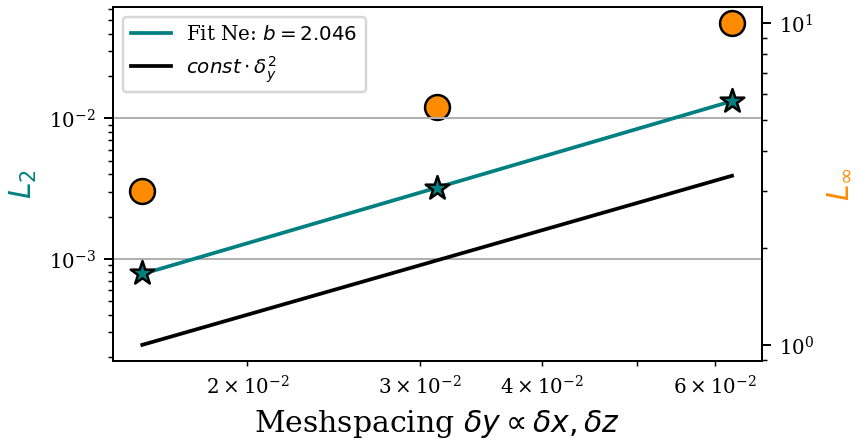

In [6]:
%matplotlib notebook
plt.close()
fig,(ax) = plt.subplots(1,1,figsize=(4.8,2.5),layout="constrained")
for key in L2:
    ax.scatter(1.0/yspacings[key],L2[key],color="teal",marker="*",s=100,edgecolor="black",zorder=10)
ax.plot(xfit,fitfunction(xfit, *popt_N),label=f'Fit {var}: $b={popt_N[1]:.3f}$',color="teal")
ax.set_yscale("log")
ax.set_xscale("log")
ax.grid()

ax.set_ylabel(r"$L_2$",color="teal")
ax.set_xlabel(r"Meshspacing $\delta y \propto \delta x,\delta z$")

ax_twin=ax.twinx()
for key in L2:
    ax.scatter(1.0/yspacings[key],Linf[key],color="darkorange",s=100,edgecolor="black")
ax_twin.set_yscale("log")
ax_twin.set_ylabel(r"$L_\infty$",color="darkorange")
ax.plot(xfit,xfit**2,color="black",label=r"$const \cdot \delta_y^2$")

ax.legend()
plt.show()